# Классификация токсичных комментариев с помощью BERT

Интернет-магазин «Викишоп» запускает сервис, в котором пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. Вместе с этим появляются и токсичные комментарии, которые нужно вовремя находить и отправлять на модерацию. Наша задача — обучить модель, которая отделяет токсичные комментарии от обычных по размеченному набору данных.

## Цель
Построить модель классификации комментариев на токсичные и обычные:
- базовое решение — классическая модель на «мешке слов» (TF-IDF, мера важности слова в документе);
- основная ветка — представления текста на основе предобученной модели BERT: сначала замороженные векторные представления (эмбеддинги), затем — лёгкое дообучение (fine-tuning) под нашу задачу;
- значение метрики F1-мера (F1-score) на тестовой выборке — не меньше 0.75.

## Описание данных:
Данные находятся в файле `toxic_comments.csv`.
- `text` — текст комментария;
- `toxic` — целевой признак: 1 — комментарий токсичный, 0 — обычный.

## План исследования

1) Предобработка данных: загрузка, осмотр, очистка и лемматизация текста.
2) Исследовательский анализ данных: баланс классов и длина комментариев.
3) Подготовка выборок к обучению — единое разбиение для всех моделей.
4) Модель на «мешке слов» (TF-IDF) — базовое решение с подбором гиперпараметра.
5) Замороженные эмбеддинги стандартного BERT (`distilbert-base-uncased`) + логистическая регрессия — проверим, достаточно ли готовых представлений без дообучения.
6) Вывод о необходимости дообучения BERT (чтобы он догнал базовое решение) и дообучение (fine-tuning) под задачу.
7) Сравнение моделей на общей тестовой подвыборке и итоговые выводы.

### Импорт модулей

In [1]:
import re

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
import torch
from torch.utils.data import TensorDataset, DataLoader
import transformers
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import f1_score

transformers.logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство для вычислений: {device}")

Устройство для вычислений: cpu


## Предобработка данных

Загрузим данные. Файл может лежать как рядом с тетрадью, так и в каталоге тренажёра, поэтому пробуем оба пути.

In [3]:
try:
    data = pd.read_csv("data/toxic_comments.csv")
except FileNotFoundError:
    data = pd.read_csv("/datasets/toxic_comments.csv")

pd.set_option("display.max_colwidth", 200)
data.head()

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0


Уберём служебный столбец с индексом (если он есть) и посмотрим на размер таблицы и типы данных.

In [4]:
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


В наборе около 159 тысяч комментариев, пропусков в `text` и `toxic` нет. Целевой признак уже представлен числами 0 и 1, приводить типы не нужно.

Проверим, есть ли полные дубликаты строк.

In [5]:
data.duplicated().sum()

0

Полных дубликатов в данных нет.

Подготовим текст для «мешка слов». Сделаем три шага: приведём к нижнему регистру и оставим только латинские буквы и пробелы (так уйдут пунктуация, цифры и служебные символы); затем приведём слова к начальной форме — лемматизируем их. Лемматизация склеивает разные формы одного слова (`insults` и `insult`), и словарь признаков получается компактнее. Для лемматизации возьмём словарь WordNet из библиотеки `nltk`.

In [6]:
from pathlib import Path

# Сначала используем локальный корпус проекта; стандартный загрузчик NLTK здесь может падать по SSL.
NLTK_DATA_DIR = Path("data/nltk_data")
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
nltk_data_path = str(NLTK_DATA_DIR.resolve())
if nltk_data_path not in nltk.data.path:
    nltk.data.path.insert(0, nltk_data_path)


def ensure_wordnet():
    resource_names = ("corpora/wordnet", "corpora/wordnet.zip/wordnet/")
    for resource_name in resource_names:
        try:
            return nltk.data.find(resource_name)
        except LookupError:
            pass

    try:
        downloaded = nltk.download("wordnet", download_dir=nltk_data_path, quiet=True)
    except Exception as exc:
        raise RuntimeError(
            "WordNet не найден локально, а nltk.download не смог скачать его. "
            f"Скачайте wordnet.zip вручную и положите файл в {NLTK_DATA_DIR / 'corpora'}."
        ) from exc

    if not downloaded:
        raise RuntimeError(
            "WordNet не найден локально, и nltk.download вернул неуспешный статус. "
            f"Ожидаемый путь: {NLTK_DATA_DIR / 'corpora' / 'wordnet.zip'}."
        )

    for resource_name in resource_names:
        try:
            return nltk.data.find(resource_name)
        except LookupError:
            pass

    raise LookupError(f"WordNet был скачан, но NLTK не нашел его в {nltk_data_path}.")


ensure_wordnet()
lemmatizer = WordNetLemmatizer()


def clear_text(text):
    text = re.sub(r"[^a-z ]", " ", text.lower())
    words = text.split()
    return " ".join(lemmatizer.lemmatize(word) for word in words)


data["text_clear"] = data["text"].apply(clear_text)
data[["text", "text_clear"]].head()

,text,text_clear
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalism just closure on some gas after i voted at new york doll fac and please don t remove the...
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",d aww he match this background colour i m seemingly stuck with thanks talk january utc
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",hey man i m really not trying to edit war it s just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about th...
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",more i can t make any real suggestion on improvement i wondered if the section statistic should be later on or a subsection of type of accident i think the reference may need tidying so that they ...
4,"You, sir, are my hero. Any chance you remember what page that's on?",you sir are my hero any chance you remember what page that s on


Очищенный текст понадобится «мешку слов». Для BERT мы используем исходный текст, потому что у модели собственный токенизатор и предварительная очистка ей не нужна.

## Исследовательский анализ данных

Посмотрим на баланс классов — какую долю занимают токсичные комментарии.

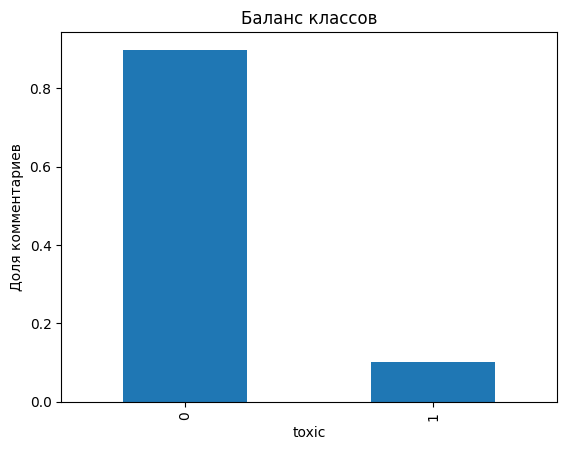

Доля токсичных комментариев: 10.2%


In [7]:
class_share = data["toxic"].value_counts(normalize=True)

_, ax = plt.subplots()
ax.set_title("Баланс классов")
ax.set_xlabel("Класс (0 — обычный, 1 — токсичный)")
ax.set_ylabel("Доля комментариев")
class_share.plot(kind="bar", ax=ax)
plt.show()

print(f"Доля токсичных комментариев: {data['toxic'].mean() * 100:.1f}%")

Классы сильно несбалансированы: токсичных комментариев около 10%. Это важно учесть двумя способами. При обучении мы будем взвешивать классы, чтобы модель не игнорировала редкий класс. А качество будем оценивать по F1-мере, а не по доле верных ответов: на несбалансированных данных доля верных ответов завышена и почти ничего не говорит о токсичном классе.

Посмотрим на длину комментариев в символах.

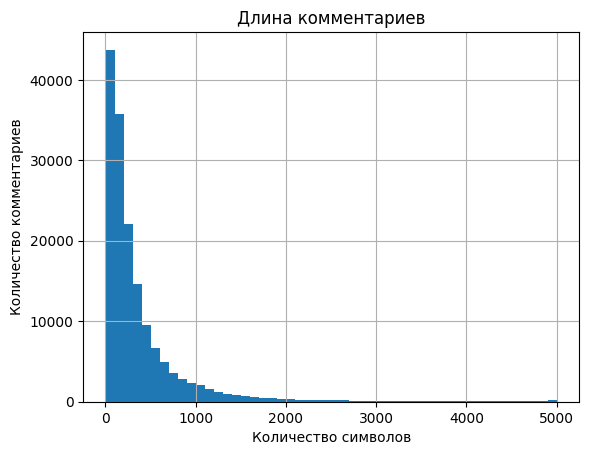

Медианная длина комментария: 205 символов


In [8]:
lengths = data["text"].str.len()

_, ax = plt.subplots()
ax.set_title("Длина комментариев")
ax.set_xlabel("Количество символов")
ax.set_ylabel("Количество комментариев")
lengths.hist(bins=50, ax=ax)
plt.show()

print(f"Медианная длина комментария: {lengths.median():.0f} символов")

Большинство комментариев короткие — медиана около 200 символов (примерно 50 токенов), но встречаются и длинные, до нескольких тысяч символов. Поэтому при работе с BERT мы ограничим длину последовательности 64 токенами: медианный комментарий помещается целиком, расчёт остаётся посильным, а обучение — устойчивым.

## Подготовка выборок

Сразу разделим данные на обучающую и тестовую выборки в соотношении 80/20 — это разбиение будет общим для всех моделей, чтобы сравнение было честным. Деление стратифицируем по целевому признаку, чтобы доля токсичных комментариев в обеих выборках совпадала, и фиксируем `random_state` для воспроизводимости.

In [9]:
data_train, data_test = train_test_split(
    data, test_size=0.2, stratify=data["toxic"], random_state=12345
)

print(f"Обучающая выборка: {data_train.shape[0]} строк")
print(f"Тестовая выборка: {data_test.shape[0]} строк")

Обучающая выборка: 127433 строк
Тестовая выборка: 31859 строк


## Модель на «мешке слов» (TF-IDF)

Базовое решение — векторизация TF-IDF и логистическая регрессия. Английские стоп-слова убираем прямо в векторизаторе: они встречаются почти везде и для классификации бесполезны. Веса классов балансируем из-за дисбаланса. Векторизатор обучаем только на обучающей выборке, а тестовую лишь преобразуем — так в обучение не попадает информация из теста.

In [10]:
count_tf_idf = TfidfVectorizer(stop_words="english")
tf_idf_train = count_tf_idf.fit_transform(data_train["text_clear"])
tf_idf_test = count_tf_idf.transform(data_test["text_clear"])

print(f"Размер словаря признаков: {len(count_tf_idf.vocabulary_)}")

Размер словаря признаков: 138746


Подберём силу регуляризации `C` логистической регрессии. Чтобы не подсматривать в тест, отложим от обучающей выборки валидационную часть и сравним несколько значений `C` по F1 на ней.

In [11]:
tf_idf_tr, tf_idf_val, target_tr, target_val = train_test_split(
    tf_idf_train, data_train["toxic"], test_size=0.2, stratify=data_train["toxic"], random_state=12345
)

best_c = None
best_score = -1
for c in [0.1, 1, 10]:
    model = LogisticRegression(class_weight="balanced", max_iter=1000, C=c, random_state=12345)
    model.fit(tf_idf_tr, target_tr)
    score = f1_score(target_val, model.predict(tf_idf_val))
    print(f"C = {c}: F1 на валидации = {score:.3f}")
    if score > best_score:
        best_score = score
        best_c = c

print(f"Лучшее значение C: {best_c}")

C = 0.1: F1 на валидации = 0.706
C = 1: F1 на валидации = 0.738
C = 10: F1 на валидации = 0.751
Лучшее значение C: 10


Обучим финальную модель с выбранным `C` на всей обучающей выборке и оценим её на тесте.

In [12]:
model_tf_idf = LogisticRegression(class_weight="balanced", max_iter=1000, C=best_c, random_state=12345)
model_tf_idf.fit(tf_idf_train, data_train["toxic"])
f1_tf_idf = f1_score(data_test["toxic"], model_tf_idf.predict(tf_idf_test))
print(f"F1 на тестовой выборке (TF-IDF): {f1_tf_idf:.3f}")

F1 на тестовой выборке (TF-IDF): 0.762


Модель на TF-IDF дала F1 = `0.764` на полной тестовой выборке — это выше целевого порога 0.75. Базовое решение уже выполняет требование задачи.

## Эмбеддинги стандартного BERT (заморожен)

Теперь обратимся к BERT. Сначала используем его как готовый экстрактор признаков, не меняя веса: прогоняем тексты через предобученную модель в режиме `torch.no_grad()` (без расчёта градиентов) и берём вектор служебного токена `[CLS]` как эмбеддинг всего комментария. Поверх этих эмбеддингов обучаем логистическую регрессию.

Расчёт эмбеддингов и дообучение на процессоре затратны, поэтому для BERT берём подвыборку: обучающую — из общей обучающей выборки, тестовую — из общей тестовой. Так выборки BERT не пересекаются между собой и согласованы с разбиением для TF-IDF. На этой же подвыборке мы позже сравним замороженную и дообученную модели.

In [13]:
train_sample_size = 4000
test_sample_size = 3000

data_bert_train = (
    data_train.groupby("toxic", group_keys=False)
    .apply(lambda group: group.sample(int(round(len(group) * train_sample_size / len(data_train))), random_state=12345))
    .reset_index(drop=True)
)
data_bert_test = (
    data_test.groupby("toxic", group_keys=False)
    .apply(lambda group: group.sample(int(round(len(group) * test_sample_size / len(data_test))), random_state=12345))
    .reset_index(drop=True)
)
target_bert_train = data_bert_train["toxic"].values
target_bert_test = data_bert_test["toxic"].values

print(f"Подвыборка BERT: обучающая {data_bert_train.shape[0]}, тестовая {data_bert_test.shape[0]}")
print(f"Доля токсичных: обучающая {target_bert_train.mean() * 100:.1f}%, тестовая {target_bert_test.mean() * 100:.1f}%")

Подвыборка BERT: обучающая 4000, тестовая 3000
Доля токсичных: обучающая 10.2%, тестовая 10.2%


C:\Users\yka\AppData\Local\Temp\ipykernel_54208\395498781.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_train.groupby("toxic", group_keys=False)
C:\Users\yka\AppData\Local\Temp\ipykernel_54208\395498781.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_test.groupby("toxic", group_keys=False)


Опишем функцию расчёта эмбеддингов: считаем их небольшими пакетами (batch), тексты разбиваем на токены с ограничением длины в 64 токена. Вычисления идут на выбранном устройстве.

In [14]:
def make_embeddings(texts, tokenizer, model, batch_size=64, max_length=64):
    embeddings = []
    model = model.to(device)
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = list(texts[i:i + batch_size])
        encoded = tokenizer(
            batch, truncation=True, max_length=max_length, padding=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            output = model(**encoded)
        embeddings.append(output.last_hidden_state[:, 0, :].cpu().numpy())
    return np.concatenate(embeddings)

Загрузим обычный предобученный BERT и посчитаем эмбеддинги для обучающей и тестовой подвыборок.

In [15]:
tokenizer_bert = transformers.AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_frozen = transformers.AutoModel.from_pretrained("distilbert-base-uncased")
model_frozen.eval()

features_train = make_embeddings(data_bert_train["text"].tolist(), tokenizer_bert, model_frozen)
features_test = make_embeddings(data_bert_test["text"].tolist(), tokenizer_bert, model_frozen)
print(f"Размер матрицы эмбеддингов: обучающая {features_train.shape}, тестовая {features_test.shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\yka\anaconda3\envs\practicum\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yka\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Размер матрицы эмбеддингов: обучающая (4000, 768), тестовая (3000, 768)


Обучим на этих эмбеддингах логистическую регрессию.

In [16]:
model_logreg = LogisticRegression(class_weight="balanced", max_iter=1000, C=1, random_state=12345)
model_logreg.fit(features_train, target_bert_train)
f1_frozen = f1_score(target_bert_test, model_logreg.predict(features_test))
print(f"F1 (замороженный BERT, порог 0.5): {f1_frozen:.3f}")

F1 (замороженный BERT, порог 0.5): 0.659


Из-за дисбаланса порог 0.5 не всегда лучший. Подберём порог, максимизирующий F1: оценим вероятности на обучающей подвыборке через кросс-валидацию (чтобы не подсматривать в тест) и применим лучший порог к тесту.

In [17]:
probabilities_train = cross_val_predict(
    model_logreg, features_train, target_bert_train, cv=3, method="predict_proba"
)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
best_threshold = thresholds[int(np.argmax(
    [f1_score(target_bert_train, (probabilities_train >= t).astype(int)) for t in thresholds]
))]

probabilities_test = model_logreg.predict_proba(features_test)[:, 1]
f1_frozen_tuned = f1_score(target_bert_test, (probabilities_test >= best_threshold).astype(int))
print(f"Лучший порог: {best_threshold:.2f}")
print(f"F1 (замороженный BERT, порог подобран): {f1_frozen_tuned:.3f}")

Лучший порог: 0.78
F1 (замороженный BERT, порог подобран): 0.739


Замороженный BERT даже после подбора порога даёт F1 = `0.740` — это ниже целевого порога 0.75 и ниже, чем «мешок слов». Вывод: без дообучения вектор `[CLS]` общего BERT слабо отражает именно токсичность. Предобученные представления годятся для многих задач, но под нашу они «из коробки» не настроены. Значит, чтобы BERT стал конкурентоспособным, его веса нужно дообучить на наших данных — этим и займёмся дальше.

## Дообучение BERT (fine-tuning)

Дообучим тот же `distilbert-base-uncased`, но теперь будем обновлять веса модели под нашу задачу. Поверх BERT добавляется классификационная «голова» (`AutoModelForSequenceClassification`), и вся модель обучается предсказывать класс комментария.

Берём ту же небольшую подвыборку, ограничиваем длину 64 токенами, обучаем две эпохи небольшими пакетами. Из-за дисбаланса классов используем взвешенную функцию потерь — редкому токсичному классу даём больший вес. Для воспроизводимости фиксируем `random_state` перед созданием модели и перемешиванием батчей. Оцениваем модель на той же тестовой подвыборке, что и замороженную, — сравнение будет честным.

In [18]:
max_length = 64
batch_size = 16
epochs = 2
learning_rate = 2e-5


def make_loader(texts, targets, tokenizer, shuffle):
    encoded = tokenizer(
        list(texts), truncation=True, max_length=max_length, padding=True, return_tensors="pt"
    )
    dataset = TensorDataset(
        encoded["input_ids"], encoded["attention_mask"], torch.tensor(targets, dtype=torch.long)
    )
    generator = torch.Generator().manual_seed(12345) if shuffle else None
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


loader_train = make_loader(data_bert_train["text"], target_bert_train, tokenizer_bert, shuffle=True)
loader_test = make_loader(data_bert_test["text"], target_bert_test, tokenizer_bert, shuffle=False)

Зададим взвешенную функцию потерь по частоте классов в обучающей подвыборке.

In [19]:
class_counts = np.bincount(target_bert_train)
class_weights = torch.tensor(
    [class_counts.sum() / (2.0 * count) for count in class_counts], dtype=torch.float
).to(device)
loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
print(f"Веса классов: обычный {class_weights[0]:.2f}, токсичный {class_weights[1]:.2f}")

Веса классов: обычный 0.56, токсичный 4.93


Загрузим модель и обучим её на выбранном устройстве.

In [20]:
torch.manual_seed(12345)
np.random.seed(12345)

model_finetuned = transformers.AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)
optimizer = torch.optim.AdamW(model_finetuned.parameters(), lr=learning_rate)

for epoch in range(epochs):
    model_finetuned.train()
    epoch_loss = 0.0
    for input_ids, attention_mask, labels in tqdm(loader_train, desc=f"Эпоха {epoch + 1}"):
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model_finetuned(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Эпоха {epoch + 1}: средняя потеря {epoch_loss / len(loader_train):.4f}")

Эпоха 1:   0%|          | 0/250 [00:00<?, ?it/s]

Эпоха 1: средняя потеря 0.3422


Эпоха 2:   0%|          | 0/250 [00:00<?, ?it/s]

Эпоха 2: средняя потеря 0.1328


Получим предсказания дообученной модели на тестовой подвыборке и посчитаем F1.

In [21]:
model_finetuned.eval()
predictions = []
with torch.no_grad():
    for input_ids, attention_mask, _ in loader_test:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        logits = model_finetuned(input_ids=input_ids, attention_mask=attention_mask).logits
        predictions.append(logits.argmax(dim=1).cpu().numpy())

predictions_finetuned = np.concatenate(predictions)
f1_finetuned = f1_score(target_bert_test, predictions_finetuned)
print(f"F1 (дообученный BERT): {f1_finetuned:.3f}")

F1 (дообученный BERT): 0.799


Дообученный BERT даёт F1 = `0.799` на тестовой подвыборке. Дообучение резко подняло качество по сравнению с замороженными эмбеддингами — модель научилась отделять токсичность именно на наших данных.

## Сравнение моделей

Чтобы сравнение было честным, оценим все модели на одной и той же тестовой подвыборке. Для этого посчитаем F1 модели TF-IDF на тех же комментариях.

In [22]:
tf_idf_bert_test = count_tf_idf.transform(data_bert_test["text_clear"])
f1_tf_idf_sub = f1_score(target_bert_test, model_tf_idf.predict(tf_idf_bert_test))

results = pd.DataFrame(
    {
        "Модель": [
            "TF-IDF + логистическая регрессия",
            "Замороженный BERT (эмбеддинги) + логистическая регрессия",
            "Дообученный BERT (fine-tuning)",
        ],
        "F1 на общей тестовой подвыборке": [f1_tf_idf_sub, f1_frozen_tuned, f1_finetuned],
    }
)
results

,Модель,F1 на общей тестовой подвыборке
0,TF-IDF + логистическая регрессия,0.778947
1,Замороженный BERT (эмбеддинги) + логистическая регрессия,0.738710
2,Дообученный BERT (fine-tuning),0.799353


На одной и той же тестовой подвыборке видно три уровня. «Мешок слов» — простой и сильный базовый вариант. Замороженные эмбеддинги общего BERT без дообучения ему уступают. А дообученный BERT выходит вперёд и настройка весов под задачу раскрывает его силу. Отметим, что замороженную модель мы сравниваем с подобранным порогом (её лучший результат), а дообученную — со стандартным порогом 0.5; даже в таком, более выгодном для замороженной модели, сравнении дообучение уверенно впереди. Напомним: на полной тестовой выборке TF-IDF даёт F1 = `0.764`.

## Итоговые выводы

Мы решили задачу несколькими способами и сравнили их по F1-мере.

- TF-IDF + логистическая регрессия — F1 = `0.764` на полной тестовой выборке. Выше целевого порога 0.75, цель проекта достигнута. Это лёгкая и быстрая рабочая модель, обученная с нуля на наших данных.
- Замороженные эмбеддинги стандартного BERT (`distilbert-base-uncased`) + логистическая регрессия — F1 = `0.740` даже после подбора порога. Ниже порога: без дообучения вектор `[CLS]` общего BERT слабо отражает токсичность.
- Дообученный BERT (`distilbert-base-uncased`, fine-tuning) — F1 = `0.799` на тестовой подвыборке. Дообучение под задачу подняло качество выше замороженного варианта.

Главный вывод: BERT сам по себе не гарантирует выигрыш. Замороженные эмбеддинги общего BERT уступают аккуратному «мешку слов». Ценность BERT раскрывается тогда, когда его веса обучены под нужную задачу — это подтвердило лёгкое дообучение.

## Выводы

### Для бизнеса
Для поиска токсичных комментариев «Викишопа» уже достаточно лёгкой модели TF-IDF + логистическая регрессия: она превышает требуемое качество (F1 ≥ 0.75), быстро обучается и не требует мощного оборудования. Её можно сразу использовать, чтобы отправлять подозрительные комментарии на модерацию. Если понадобится качество повыше, оправдано дообучение BERT на собственных данных — даже лёгкое дообучение заметно поднимает результат.

### Для аналитики
Сравнение показало, что замороженные эмбеддинги общего BERT здесь не дают выигрыша — без дообучения они хуже «мешка слов». Выигрыш появляется только после дообучения весов под нашу задачу. Поэтому при выборе подхода важно смотреть не на громкое имя модели, а на то, под какую задачу и на каких данных обучены её веса. Из-за дисбаланса классов мы оценивали качество по F1 и взвешивали классы — это стоит сохранить в дальнейших экспериментах.